# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency

### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv('C:\\Users\JGO Gamer\Documents\Projects\Project-NovaRetail/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  str    
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  str    
 10  region                     15000 non-null  str    
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), str(3)
memory usage: 1.4 MB


<>:2: SyntaxWarning: "\J" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\J"? A raw string is also an option.
<>:2: SyntaxWarning: "\J" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\J"? A raw string is also an option.
C:\Users\JGO Gamer\AppData\Local\Temp\ipykernel_9084\3417179272.py:2: SyntaxWarning: "\J" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\J"? A raw string is also an option.
  df = pd.read_csv('C:\\Users\JGO Gamer\Documents\DA Git projects\Project-NovaRetail/novaretail_comportamiento_clientes_2024.csv')


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satifacción`
- `miembro_premium`
- `abandono`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `edad` tiene tipo de dato float.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype(int)

# verificar cambios
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  str    
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  str    
 10  region                     15000 non-null  str    
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), str(3)
memory usage: 1.4 MB


#### Explorar variables numéricas

In [ ]:
#Creación de función para automatizar la clasificación de columnas
def clasificar_columnas(df):
    #Lista 1: Todas las columnas
    todas_columnas = list(df.columns)
        
    #Lista 2: numéricas y boleanas
    numeros = list(df.select_dtypes(include=['int64', 'float64']).columns)
    numericas = []
    booleanas = []
    for col in numeros:
        booleanos = set(df[col].unique())
        if booleanos == {0 , 1} or booleanos == {0} or booleanos == {1}:
            booleanas.append(col) #Detectar booleanos
        else:
            numericas.append(col) #Detectar no booleanos
    
    #Lista 3: no numéricas
    no_numericas = list(df.select_dtypes(exclude=['int64', 'float64']).columns)

    return todas_columnas, numericas, booleanas, no_numericas
    
# Estadísticas descriptivas de variables numéricas

todas_columnas, numericas, booleanas, no_numericas = clasificar_columnas(df)
print()
print('OBTENCIÓN DE LA MEDIANA')
print(df[numericas].median())
print()
print('OBTENCIÓN DE LA ESTADÍSTICA DESCRIPTIVA')
df[numericas].describe()


OBTENCIÓN DE LA MEDIANA
edad                            38.000
nivel_ingreso                30023.745
visitas_mes                     10.000
compras_mes                      1.000
gasto_publicidad_dirigida       19.730
satisfaccion                     3.600
ingreso_anual                   30.705
dtype: float64

OBTENCIÓN DE LA ESTADÍSTICA DESCRIPTIVA


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000



***Diagnóstico inicial de variables numéricas***

- `edad` — promedio 38 años
- `nivel ingreso` estimado del usuario - aproximado de $30,000.00.
- `visitas mes` y `compras_mes` - se sugiere una conversión aproximada del 10% (10 visitas = 1 compra) en promedio mensual
- `gasto publicidad dirigida` - se observa que al incrementar la publicidad hay un incremento en las visitas al igual que en las ventas.
- `satifacción` - Se observa que los usuarios de mayor ingreso (del cuartil 0.5 hacia arriva) asignan una calificación de 5.
- `ingreso anual` - Se observa que los ingresos por el segmento premium son 4.5 veces mayor que el promedio.

Observaciones adicionales: 

1.- Al comparar la mediana con la media de las columnas, son similares sugiriendo que la distribución de los datos es normal.

2.- En la estadística descriptiva no se observa ouliers. 

#### Explorar variables binarias

In [ ]:
#Exploración valores booleanos
print('Tabla de columnas booleanas')
print()
df[booleanas].describe()

Tabla de columnas booleanas



,miembro_premium,abandono
count,15000.000000,15000.000000
mean,0.139267,0.150733
std,0.346236,0.357801
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,1.000000,1.000000



***Diagnóstico inicial de variables binarias***


- `miembro premium` - se puede sugerir que este segmento está satisfecho con el servicio, ya que su calificación es el máximo
- `abandono` - se observa que el segmento miembro premium permanece activo, mientras que el otro segmento no.

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
todas_columnas, numericas, booleanas, no_numericas = clasificar_columnas(df)

valores_unicos = pd.DataFrame({
    'Columna': no_numericas,
    'valores_unicos': [df[col].nunique() for col in no_numericas]
})
print('OBTENCIÓN DE LA ESTADÍSTICA DESCRIPTIVA')
print(valores_unicos.sort_values(by='valores_unicos',ascending=False).to_string(index=False))

OBTENCIÓN DE LA ESTADÍSTICA DESCRIPTIVA
         Columna  valores_unicos
      id_cliente           15000
          region               4
tipo_dispositivo               3


In [ ]:
# Explorar variables categóricas y cómo se distribuyen
todas_columnas, numericas, booleanas, no_numericas = clasificar_columnas(df)
print()
print('OBTENCIÓN DE LA ESTADÍSTICA DESCRIPTIVA')
df[no_numericas].describe()


OBTENCIÓN DE LA ESTADÍSTICA DESCRIPTIVA


,id_cliente,tipo_dispositivo,region
count,15000,15000,15000
unique,15000,3,4
top,CL-100000,móvil,norte
freq,1,9818,4395


***Diagnóstico inicial de variables categóricas***

- `tipo_dispositivo` — Se observa que más del 65% acceden por móvil.
- `región` - Se observa que la región norte presenta mayores usuarios.
- `id_cliente`- No se observa detalles relevantes.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

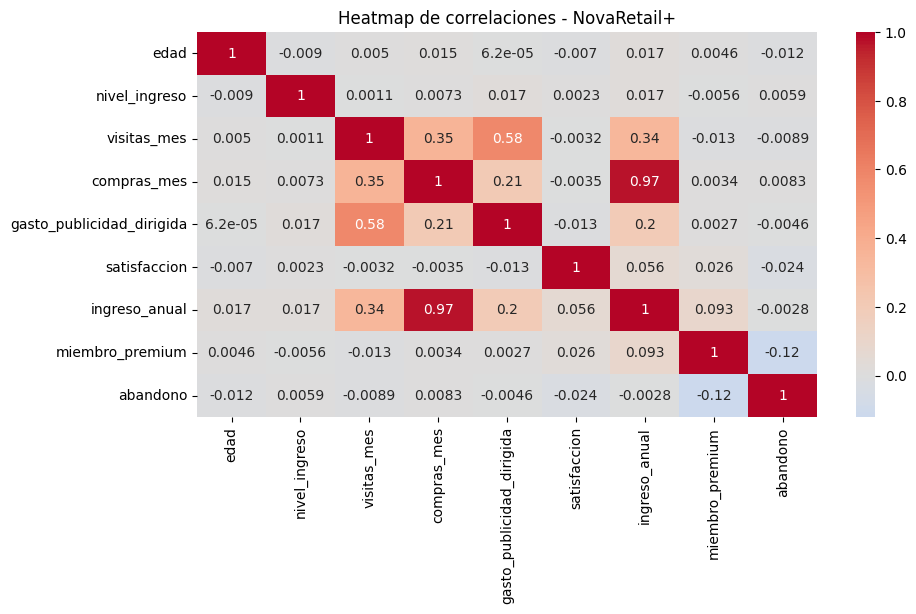

Tabla de correlaciones exploratorio ordenada por magnitud: 
                    columna_1                  columna_2  correlacion
0               ingreso_anual                compras_mes     0.967149
1   gasto_publicidad_dirigida                visitas_mes     0.578947
2                 compras_mes                visitas_mes     0.353844
3               ingreso_anual                visitas_mes     0.337147
4   gasto_publicidad_dirigida                compras_mes     0.207528
5               ingreso_anual  gasto_publicidad_dirigida     0.197483
6             miembro_premium              ingreso_anual     0.093099
7               ingreso_anual               satisfaccion     0.056171
8             miembro_premium               satisfaccion     0.025734
9               ingreso_anual                       edad     0.017496
10              ingreso_anual              nivel_ingreso     0.017446
11  gasto_publicidad_dirigida              nivel_ingreso     0.016834
12                compras_mes 

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones

columnas_num_bool = numericas + booleanas
matriz_corr = df[columnas_num_bool].corr()

plt.figure(figsize=(10,5))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', center=0)
plt.title('Heatmap de correlaciones - NovaRetail+')
plt.show()
    
#Crear tabla con todos los pares de correlación
def crear_tabla_correlaciones(tabla_corr):
    #Convertir la matriz a formato largo(pares de variables)
    
    correlaciones = []

    #Obtener nombres de las columnas
    
    columnas_corr = tabla_corr.columns

    #Iterar sobre todas las combinaciones de variables
    for i in range (len(columnas_corr)):
        for j in range (i+1, len(columnas_corr)): #i+1 para evitar duplicados y diagonal
            var1 = columnas_corr[j]
            var2 = columnas_corr[i]
            correlación = tabla_corr.iloc[j,i]
            correlaciones.append({
                'columna_1': var1,
                'columna_2': var2,
                'correlacion': correlación,
            })
    #Crear DataFrame y ordenar por correlación absoluta
    df_correlaciones = pd.DataFrame(correlaciones)
    df_correlaciones = df_correlaciones.sort_values('correlacion', ascending = False)

    return df_correlaciones

#Aplicar la función
tabla_correlaciones = crear_tabla_correlaciones(matriz_corr)
print('Tabla de correlaciones exploratorio ordenada por magnitud: ')

#Impresión de tabla de correlaciones
Set_correlacion_exploratorio = 0.005      #Cambia el valor de correlación para analisis exploratorio
tabla_correlaciones_exploratorio = tabla_correlaciones[tabla_correlaciones['correlacion'] >= Set_correlacion_exploratorio]
print(tabla_correlaciones_exploratorio.sort_values(by='correlacion',ascending=False).reset_index(drop=True))

Observaciones generales (Heatmap)  
- Se observan 6 correlaciones fuertes:
- 1.- `ingreso_anual`                `compras_mes`     0.967149
- 2.- `gasto_publicidad_dirigida`    `visitas_mes`     0.578947
- 3.- `compras_mes`                  `visitas_mes`     0.353844
- 4.- `ingreso_anual`                `visitas_mes`     0.337147
- 5.- `gasto_publicidad_dirigida`    `compras_mes`     0.207528
- 6.- `ingreso_anual`  `gasto_publicidad_dirigida`     0.197483
        
De la cual como es de esperarse al incrementar las `compras_mes` es directamente proporcional al `ingreso_anual`. Se observa también que el `gasto_publicidad_dirigida` tiene una correlación fuerte con `visitas_mes` y por ende, con `compras_mes` e `ingreso_anual`, lo cual sugiere que la inversión en publicidad está funcionando, aunque habrá que segmentar el análisis para un análisis más profundo. `compras_mes` e `ingreso_mensual` muestran una correlación fuerte con `visitas_mes` lo cual es de esperarse, ya que al tener más visitas, naturalmente incrementa la posibilidad de compra y mayores ingresos. 

Observaciones respecto a `ingreso_anual`  
- Presenta relación con `compras_mes`, `visitas_mes`, `gasto_publicidad_dirigida`, `miembro_premium`,
 `satisfaccion`, `edad` y `nivel_ingreso`, principalmente con las primeras tres.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - N/A
    

- **Si decides no incluirlo**:
  - En mi análisis no vi la necesidad de usar un scatterplot general, ya que se observan varios patrones claros. De los cuales acontinuación desglosaré uno por uno.


Tabla de correlaciones final ordenada con un valor asignado de:  0.19
                   columna_1                  columna_2  correlacion
0              ingreso_anual                compras_mes     0.967149
1  gasto_publicidad_dirigida                visitas_mes     0.578947
2                compras_mes                visitas_mes     0.353844
3              ingreso_anual                visitas_mes     0.337147
4  gasto_publicidad_dirigida                compras_mes     0.207528
5              ingreso_anual  gasto_publicidad_dirigida     0.197483

Desviación estandar de las columnas utilizadas
                     Columna    std
0                visitas_mes   3.16
1              ingreso_anual  34.48
2  gasto_publicidad_dirigida  10.88
3                compras_mes   1.11



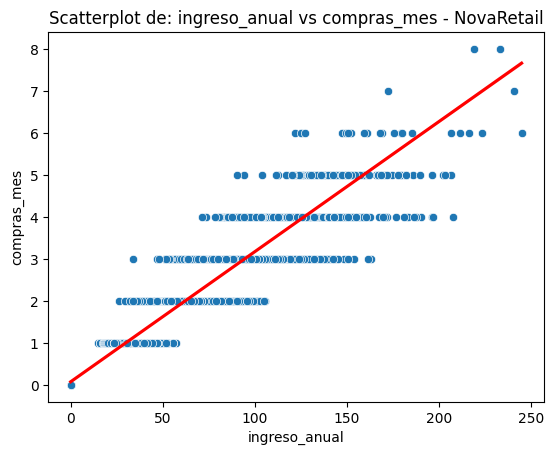

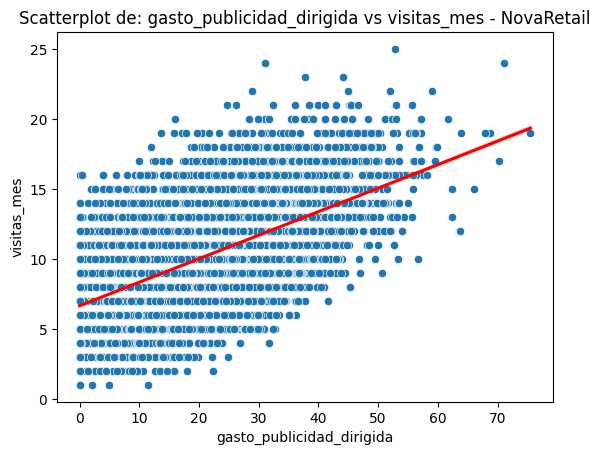

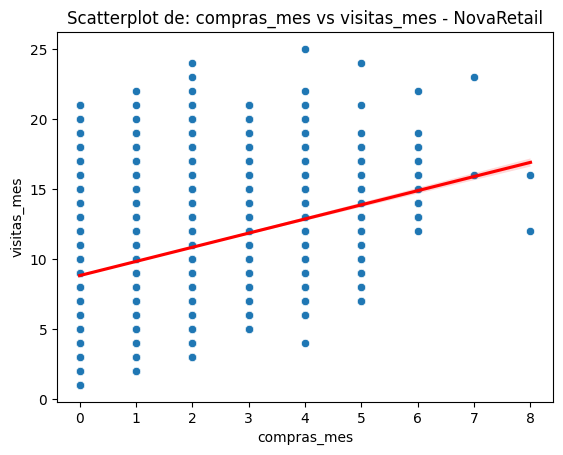

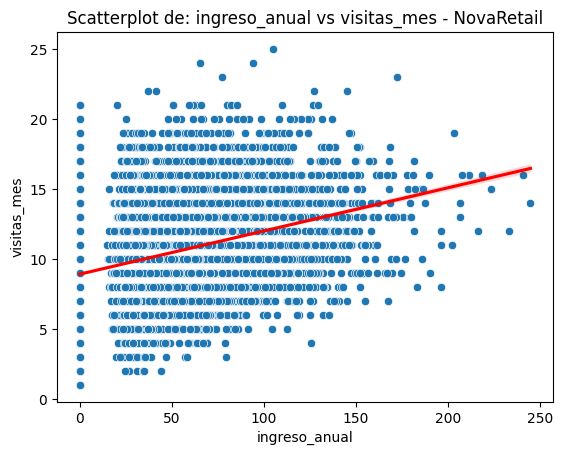

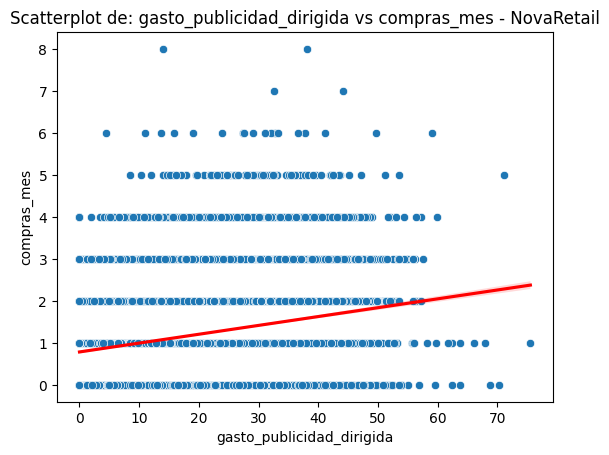

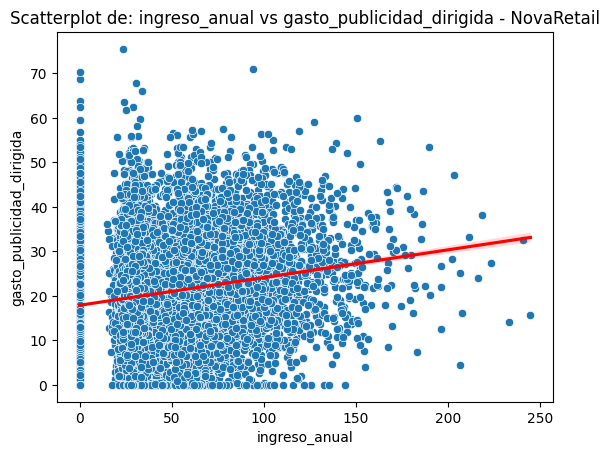

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes

#Asignación de valor de correlación con base al resultado del heatmap 

set_correlacion_final = 0.19 #Asigna un valor de correlación

#Impresión de tabla de acuerdo al valor asignado de correlación a analizar
tabla_corr_final = tabla_correlaciones[tabla_correlaciones['correlacion'] >= set_correlacion_final]

print()
print('Tabla de correlaciones final ordenada con un valor asignado de: ', set_correlacion_final)
print(tabla_corr_final.sort_values(by='correlacion',ascending=False).reset_index(drop=True))
print()

# Impresión de gráficos y creación de tabla con columnas utilizadas para el scatterplot
df_scatterplot = tabla_corr_final[['columna_1','columna_2']]

df_columnas_scatterplot = list(set(df_scatterplot['columna_1'].tolist() + df_scatterplot['columna_2'].tolist()))
print('Desviación estandar de las columnas utilizadas')

tabla_df_columnas_scatterplot = pd.DataFrame({
    'Columna': df_columnas_scatterplot,
    'std': [df[col5].std() for col5 in df_columnas_scatterplot]
})
print(tabla_df_columnas_scatterplot.round(2))
print()

#Bucle for para graficar en scatterplot
for index, row in df_scatterplot.iterrows():
    col1 = row['columna_1']
    col2 = row['columna_2']
    
    sns.scatterplot(data=df, x= col1, y= col2)
    sns.regplot(data=df, x= col1, y= col2, scatter=False ,color='red')
    plt.title(f'Scatterplot de: {col1} vs {col2} - NovaRetail')
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.show()
    print()


***Observaciones iniciales (Scatterplot)***

**ingreso_anual vs compras_mes**
- Dirección positiva con una correlación 0.96, prácticamente comportamiento lineal, los datos tienen dispersión baja.

**gasto_publicidad_dirigida vs visitas_mes**
- Dirección positiva con una correlación de 0.57, comportamiento ligeramente lineal, los datos tienen dispersión media.

**compras_mes vs visitas_mes**
- Dirección positiva con una correlación de 0.35, comportamiento lineal pobre, los datos tienen dispersión media-alta.

- **ingreso_anual vs visitas_mes**
- Dirección positiva con una correlación de 0.33, comportamiento lineal pobre, los datos tienen dispersión media-alta.

- **gasto_publicidad_dirigida vs compras_mes**
- Dirección positiva con una correlación de 0.20, comportamiento lineal pobre, los datos tienen dispersión alta.

- **gasto_publicidad_dirigida vs compras_mes**
- Dirección positiva con una correlación de 0.20, comportamiento lineal pobre, los datos tienen dispersión alta.

 **ingreso_anual vs gasto_publicidad_dirigida**
- Dirección positiva con una correlación de 0.19, comportamiento lineal pobre, los datos tienen dispersión alta.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes

# Creación de la función
def numeric_corr(df_col_num):
    
    tabla_correlaciones = pd.DataFrame(columns=['variable_1', 'variable_2', 'pearson', 'spearman'])
    
        # Listas para almacenar los resultados
    columna_1 = []
    columna_2 = []
    correlacion_pearson = []
    correlacion_spearman = []
    
    # Bucle para calcular correlaciones
    for index, row in df_col_num.iterrows():
        col1 = row['columna_1']
        col2 = row['columna_2']
        
        if pd.api.types.is_numeric_dtype(df[col1]) and pd.api.types.is_numeric_dtype(df[col2]):
            # Calculo de correlaciones
            pearson_corr = df[col1].corr(df[col2], method='pearson')
            spearman_corr = df[col1].corr(df[col2], method='spearman')
        
            # Almacenar en las listas
            columna_1.append(col1)
            columna_2.append(col2)
            correlacion_pearson.append(round(pearson_corr, 3))
            correlacion_spearman.append(round(spearman_corr, 3))

    # SOLUCIÓN: Alineado perfectamente fuera del bucle 'for'
        
        if len(columna_1) > 0:
            tabla_correlaciones = pd.DataFrame({
                'variable_1': columna_1,
                'variable_2': columna_2,
                'pearson': correlacion_pearson,
                'spearman': correlacion_spearman
    })
  
    return tabla_correlaciones

# Uso de la función
tabla_resultados = numeric_corr(df_scatterplot)
print('tabla correlaciones:')
print(tabla_resultados)

tabla correlaciones:
                  variable_1                 variable_2  pearson  spearman
0              ingreso_anual                compras_mes    0.967     0.967
1  gasto_publicidad_dirigida                visitas_mes    0.579     0.559
2                compras_mes                visitas_mes    0.354     0.333
3              ingreso_anual                visitas_mes    0.337     0.321
4  gasto_publicidad_dirigida                compras_mes    0.208     0.193
5              ingreso_anual  gasto_publicidad_dirigida    0.197     0.185


***Observaciones de correlación***

**ingreso_anual vs compras_mes**
- Dirección: positiva.
- Magnitud: 0.967 en ambos métodos.
- Colinealidad: fuerte

**gasto_publicidad_dirigida vs visitas_mes**
- Dirección: positiva.
- Magnitud: 0.579 similares ambos métodos.
- Colinealidad: moderada

**compras_mes vs visitas_mes**
- Dirección: positiva.
- Magnitud: 0.354 similares ambos métodos.
- Colinealidad: moderada

**ingreso_anual vs visitas_mes**
- Dirección: positiva.
- Magnitud: 0.337 similares ambos métodos.
- Colinealidad: moderada

**gasto_publicidad_dirigida vs compras_mes**
- Dirección: positiva.
- Magnitud: 0.208 similares ambos métodos.
- Colinealidad: ligera

**ingreso_anual vs gasto_publicidad_dirigida**
- Dirección: positiva.
- Magnitud: 0.197 similares ambos métodos.
- Colinealidad: ligera

### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes

#Ciclo for para iterar entre columnas booleanas y numéricas

correlaciones_biserial = []

for var_bool in booleanas:
    for var_num in numericas:
        correlacion_biserial, p_val = pointbiserialr(df[var_bool], df[var_num])
        correlaciones_biserial.append({
            'booleanos': var_bool,
            'numericas': var_num,
            'resultado': round(correlacion_biserial,3),
            'p_valor': round(p_val,3),
        })
tabla_correlaciones_biserial = pd.DataFrame(correlaciones_biserial).sort_values('resultado', ascending = False)
tabla_correlaciones_biserial_final = tabla_correlaciones_biserial[tabla_correlaciones_biserial['p_valor'] <= 0.05]
print()
print('Tabla de correlaciones biseriales estadísticamente significativa (p_value <= 0.05)')
print()
print(tabla_correlaciones_biserial_final.reset_index(drop=True))
print()


Tabla de correlaciones biseriales estadísticamente significativa (p_value <= 0.05)

         booleanos      numericas  resultado  p_valor
0  miembro_premium  ingreso_anual      0.093    0.000
1  miembro_premium   satisfaccion      0.026    0.002
2         abandono   satisfaccion     -0.024    0.004



In [ ]:
#creación de tabla de satisfacción de todos los usuarios
def crear_rangos_satisfaccion(df, columna, min_val, max_val, n):
    #Crear rangos automáticamente
    bins = list(range(min_val, max_val + n))
    labels = [f"{i} - {i+n}" for i in range(min_val, max_val)]

    df[f'rango_{columna}'] = pd.cut(df[columna],
                                    bins=bins,
                                    labels=labels,
                                    include_lowest=True)
    return df

# Uso para escala ajustada
rango_satisfaccion = crear_rangos_satisfaccion(df, 'satisfaccion', 0, 5, 1)

tabla_satisfaccion = df.groupby('rango_satisfaccion').agg({
    'miembro_premium': 'sum',
    'abandono': lambda x: (x==0).sum()
})
tabla_satisfaccion = tabla_satisfaccion.rename(columns={'abandono': 'miembro_normal'})

#Establece el número total de usuarios
usuarios = 15000

total_usuarios = tabla_satisfaccion.sum().sum()
abandono = (usuarios - total_usuarios) / usuarios * 100

tabla_satisfaccion_porcentaje = (tabla_satisfaccion / usuarios) * 100
tabla_satisfaccion_porcentaje = tabla_satisfaccion_porcentaje.round(2)

print('Tabla de calificación de los usuarios activos')
print(tabla_satisfaccion_porcentaje )
print(f"Nota: abandono del {abandono:.2f}%")

Tabla de calificación de los usuarios activos
                    miembro_premium  miembro_normal
rango_satisfaccion                                 
0 - 1                          0.00            0.01
1 - 2                          0.13            1.12
2 - 3                          2.50           16.52
3 - 4                          7.51           44.51
4 - 5                          3.79           22.76
Nota: abandono del 1.15%


***Observaciones Punto-biserial***

**miembro_premium vs ingreso_anual**
- Dirección: positiva.
- magnitud: 0.093 (baja)
- p_value: 0.000 (estadísticamente significativa)

**miembro_premium vs satisfacción**
- Dirección: positiva.
- magnitud: 0.026 (baja)
- p_value: 0.002 (estadísticamente significativa)

**abandono vs satisfacción**
- Dirección: negativo
- magnitud: 0.024 (baja)
- p_value: 0.004 (estadísticamente significativa)

### V de Cramér

In [ ]:
# Función para calcular V de Cramér

def correlacion_v_cramer(columnas_no_numericas):
    resultados = []
    #Se usa la clasificación "no_numericas"
    for i in range (len(columnas_no_numericas)):
        for j in range (i+1, len(columnas_no_numericas)):
            col1 = columnas_no_numericas[i]
            col2 = columnas_no_numericas[j]
            
            #Creación tabla de contingencia
            tabla_contingencia = pd.crosstab(df[col1], df[col2])
            #Calculo del chi2
            chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
            #Cálculo de n
            n = tabla_contingencia.sum().sum()
            #Cálculo V de cramer
            v_cramer = np.sqrt(chi2/(n*(min(tabla_contingencia.shape) - 1 )))
            resultados.append({
                'columna_1': col1,
                'columna_2': col2,
                'coeficiente_v_cramer': v_cramer,
            })
    return resultados

tabla_correlaciones_v_cramer = correlacion_v_cramer(no_numericas)
tabla_correlaciones_v_cramer = pd.DataFrame(tabla_correlaciones_v_cramer).sort_values('coeficiente_v_cramer',ascending=False)

# Aplicar V de Cramér en variables relevantes
print(tabla_correlaciones_v_cramer)

    

          columna_1         columna_2  coeficiente_v_cramer
0        id_cliente  tipo_dispositivo              1.000000
1        id_cliente            region              1.000000
2  tipo_dispositivo            region              0.012378


In [ ]:
#
dispositivos = df[['tipo_dispositivo', 'region']].value_counts(normalize=True).sort_values(ascending=False)
print(dispositivos.round(2))

tipo_dispositivo  region
móvil             norte     0.19
                  oeste     0.17
                  sur       0.17
                  este      0.13
escritorio        norte     0.08
                  oeste     0.06
                  sur       0.06
                  este      0.05
tablet            norte     0.03
                  oeste     0.03
                  sur       0.02
                  este      0.02
Name: proportion, dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

Observaciones V de Cramér
-Se observa claramente que la relación entre `id_cliente` vs `tipo_dispositivo` y `id_cliente` vs `region` tienen una relación de 1, lo cual es una relación perfecta, ya que hay 15,000 usuarios que es l número total de la base de datos y por ende no hay variabilidad con respecto a tipo de dispositivo y región, por tanto, se descartan estas dos relaciones.

- La tercera relación, tiene un resultado de 0.012378 es una relación baja, casi nula. Revisando el porcentaje de dispositivo por región, se observa que el `movil` representa mayor uso por región.


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

### Hallazgo 1 — 

**Evidencia visual: ingreso_anual vs compras_mes**   

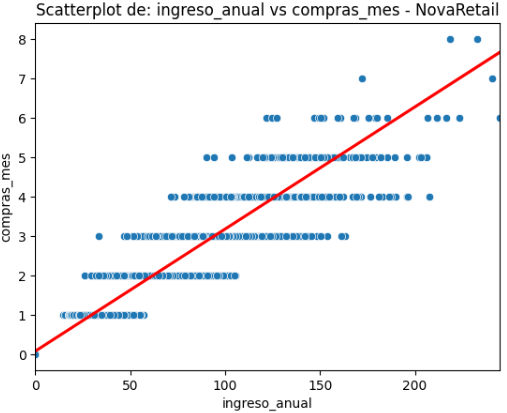

**Evidencia numérica: método Pearson** 
- 0.967

**Interpretación** 
- Dirección positiva con una correlación 0.967, prácticamente comportamiento lineal, los datos tienen dispersión baja, colinealidad fuerte.
- Comportamiento esperado, ya que las `compras_mes` es directamente proporcional al `ingreso anual`.

**No podemos afirmar**  
- Todos los usuarios compran.

**Implicación de negocio**  
- Para incrementar los ingresos anuales, se tiene que incentivar que los usuarios realicen compras.

### Hallazgo 2 — 

**Evidencia visual: gasto_publicidad_dirigida vs visitas_mes**   

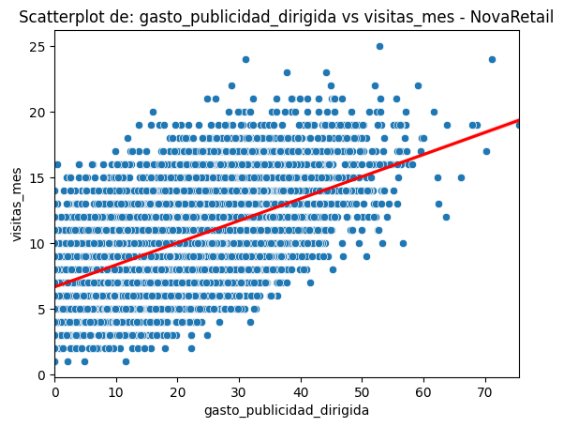

**Evidencia numérica: método Pearson** 
- 0.579

**Interpretación**  
- Dirección positiva con una correlación de 0.57, comportamiento ligeramente lineal, los datos tienen dispersión media, colinealidad: moderada.
- Comportamiento lógico esperado, ya que al invertir en `gasto_publicidad_dirigida` tiende a incrementar el número de visitantes.

**No podemos afirmar**  
- Que todas las inversiones en campañas sean efectivas, ya que se trata de una correlación moderada.

**Implicación de negocio**  
- Desarrollar publicidad que atraigan más usuarios y realicen compras.

### Hallazgo 3 — 

**Evidencia visual: compras_mes vs visitas_mes**   

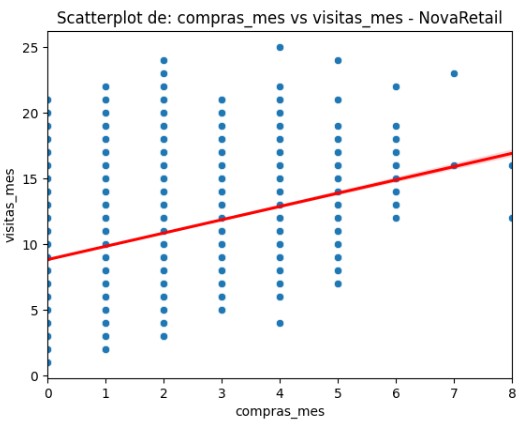

**Evidencia numérica: método Pearson** 
- 0.354

**Interpretación**  
- Dirección positiva con una correlación de 0.354, comportamiento lineal pobre, los datos tienen dispersión media-alta, colinealidad: moderada.
- Comportamiento lógico esperado, ya que los usuarios que visitan no siempre compran, por otra parte, al incrementar el número de visitas incrementa la probabilidad de compra.

**No podemos afirmar**  
- Que todos los usuarios que visitan realicen compras, ya que se trata de una correlación moderada.

**Implicación de negocio**  
- Para incrementar las ventas, se requiere que incremente el número de visitas de los usuarios.

### Hallazgo 4 — 

**Evidencia visual: ingreso_anual vs visitas_mes**   

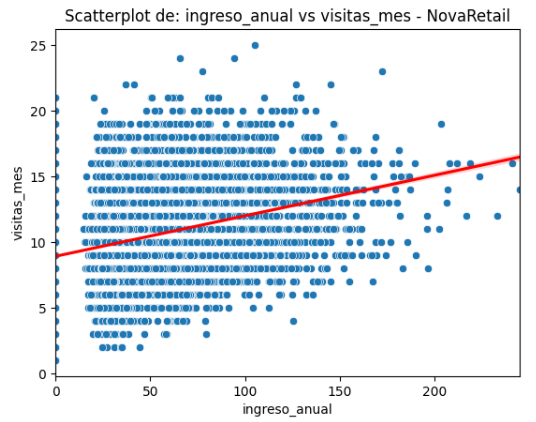

**Evidencia numérica: método Pearson** 
- 0.337

**Interpretación**  
- Dirección positiva con una correlación de 0.337, comportamiento lineal pobre, los datos tienen dispersión media-alta, colinealidad: moderada.
- Comportamiento lógico esperado, ya que los usuarios que visitan no siempre compran, por otra parte, al incrementar el número de visitas incrementa la probabilidad de compra.

**No podemos afirmar**  
- Que todos los usuarios que visitan realicen compras, ya que se trata de una correlación moderada.

**Implicación de negocio**  
- Para incrementar las ventas, se requiere que incremente el número de visitas de los usuarios.

### Hallazgo 5 — 

**Evidencia visual: gasto_publicidad_dirigida vs compras_mes**   

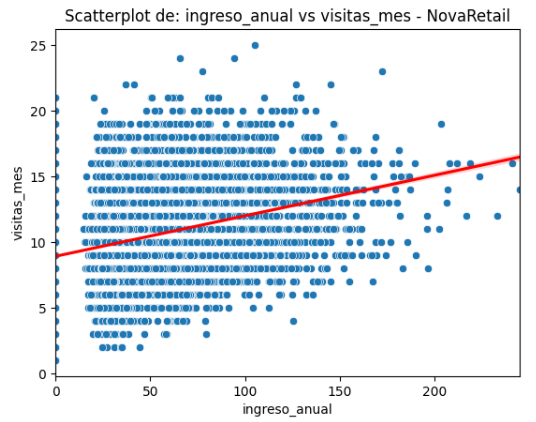

**Evidencia numérica: método Pearson** 
- 0.208

**Interpretación**  
- Dirección positiva con una correlación de 0.208, comportamiento lineal pobre, los datos tienen dispersión alta, colinealidad: ligera.
- Comportamiento lógico esperado, ya que las campañas de publicidad bien planeadas pueden incrementar la visita de usuarios, que al incrementar el número de visitas incrementa la probabilidad de compra.

**No podemos afirmar**  
- Que todas las campañas sean efectivas, ya que se trata de una correlación ligera.

**Implicación de negocio**  
- Desarrollar campañas eficientes, para atraer el mayor número de usuarios que al visitar, realicen compras.

### Hallazgo 6 — 

**Evidencia visual: ingreso_anual vs gasto_publicidad_dirigida**   

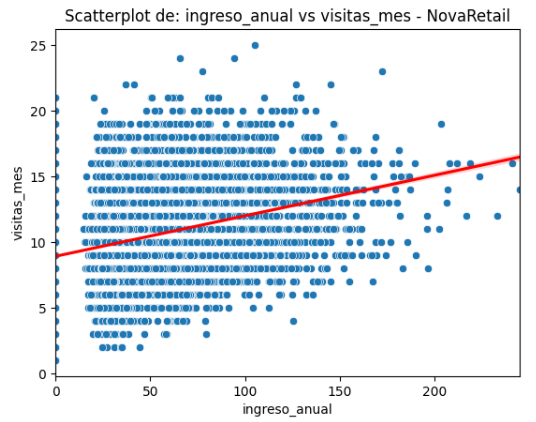

**Evidencia numérica: método Pearson** 
- 0.197

**Interpretación**  
- Dirección positiva con una correlación de 0.197, comportamiento lineal pobre, los datos tienen dispersión alta, colinealidad: ligera.
- Comportamiento lógico esperado, ya que las campañas de publicidad bien planeadas pueden incrementar la visita de usuarios, que al incrementar el número de visitas incrementa la probabilidad de compra.

**No podemos afirmar**  
- Que todas las campañas sean efectivas, ya que se trata de una correlación ligera.

**Implicación de negocio**  
- Desarrollar campañas eficientes, para atraer el mayor número de usuarios que al visitar, realicen compras.

### Hallazgo 7 — 

**Evidencia visual: miembro_premium vs ingreso_anual**   
- N/A

**Evidencia numérica: Punto biserial** 
- 0.093

**Interpretación**  
- Dirección: positiva.
- magnitud: 0.093 (baja)
- p_value: 0.000 (estadísticamente significativa)
- Se sugiere que el segmento de `miembros_premium` destaca ligeramente en el ingreso anual.

**No podemos afirmar**  
- Que los usuarios premium compren más que los usuarios no premium.

**Implicación de negocio**  
- Incentivar a los usuarios premium a que compren.

### Hallazgo 8 — 

**Evidencia visual: miembro_premium vs satisfacción y abandono vs satisfacción**   
- N/A

**Evidencia numérica: Punto biserial** 
- 0.026 y -.0.024

**Interpretación**  

*miembro_premium vs satisfacción*
- Dirección: positiva.
- magnitud: 0.026 (baja)
- p_value: 0.002 (estadísticamente significativa)

*abandono vs satisfacción*
- Dirección: negativo
- magnitud: 0.024 (baja)
- p_value: 0.004 (estadísticamente significativa)
- 
*Conjunto*
- Al realizar una segmentación de la calificación del nivel de satisfacción, se observa que el 11% de los usuarios son `premium` siendo una pequeña parte de la población, coincide con la baja correlación que presenta.
- Por el contrario, el abandono solo representa 1.15% de la población, mientras que los `miembro_normal` representa el 67% de la problación y al cambiar el enfoque, se observa que también el cliente normal presenta un alto nivel de satisfacción.

**No podemos afirmar**  
- Que los usuario que abandonaron representa una insatisfacción general, ya que solo representa el 1.15% total de los usuarios registrados.

**Implicación de negocio**  
- En general el 79% de los usuarios tienen una muy buena satisfacción con los productos/serivcios.

✍️ **Hallazgos**: Sumario de tablas creadas

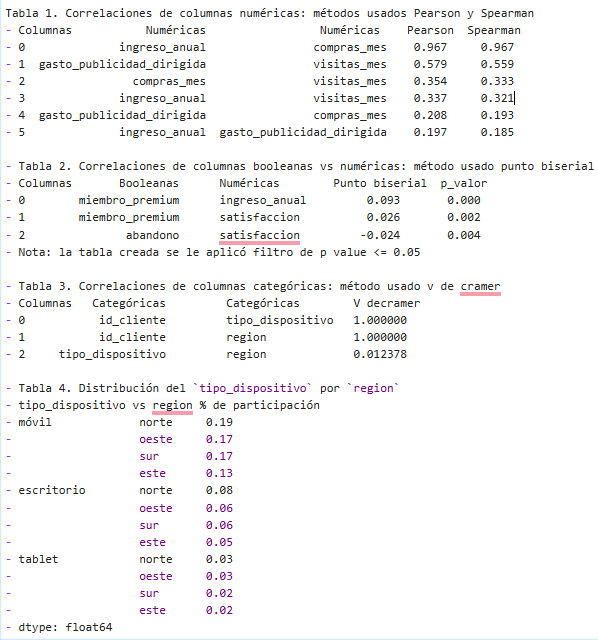

Tabla 1. Correlaciones de columnas numéricas: métodos usados Pearson y Spearman
- Columnas           Numéricas                 Numéricas    Pearson  Spearman
- 0              ingreso_anual                compras_mes    0.967     0.967
- 1  gasto_publicidad_dirigida                visitas_mes    0.579     0.559
- 2                compras_mes                visitas_mes    0.354     0.333
- 3              ingreso_anual                visitas_mes    0.337     0.321
- 4  gasto_publicidad_dirigida                compras_mes    0.208     0.193
- 5              ingreso_anual  gasto_publicidad_dirigida    0.197     0.185

- Tabla 2. Correlaciones de columnas booleanas vs numéricas: método usado punto biserial
- Columnas       Booleanas      Numéricas        Punto biserial  p_valor
- 0        miembro_premium      ingreso_anual         0.093       0.000
- 1        miembro_premium      satisfaccion          0.026       0.002
- 2               abandono      satisfaccion         -0.024       0.004
- Nota: la tabla creada se le aplicó filtro de p value <= 0.05

-Tabla 3. Calificación de los usuarios activos (porcentaje)
- rango_satisfaccion       miembro_premium  miembro_normal                          
-      0 - 1                          0.00            0.01
-      1 - 2                          0.13            1.12
-      2 - 3                          2.50           16.52
-      3 - 4                          7.51           44.51
-      4 - 5                          3.79           22.76
Nota: abandono del 1.15%

- Tabla 4. Correlaciones de columnas categóricas: método usado v de cramer
- Columnas   Categóricas         Categóricas        V decramer
- 0           id_cliente         tipo_dispositivo   1.000000
- 1           id_cliente         region             1.000000
- 2     tipo_dispositivo         region             0.012378

- Tabla 5. Distribución del `tipo_dispositivo` por `region`
- tipo_dispositivo vs region % de participación
- móvil             norte     0.19
-                   oeste     0.17
-                   sur       0.17
-                   este      0.13
- escritorio        norte     0.08
-                   oeste     0.06
-                   sur       0.06
-                   este      0.05
- tablet            norte     0.03
-                   oeste     0.03
-                   sur       0.02
-                   este      0.02
- dtype: float64

### Hallazgo 9 — 

**Evidencia visual: tipo_dispositivo vs region**   
- N/A

**Evidencia numérica: v de cramer** 
- 0.012

**Interpretación**  
- Dirección: positiva.
- magnitud: 0.012 (baja)
- Se observa una correlación baja, indicando que de manera global no hay afectación. Al segmentar por dispositivo y por región, se observa que al menos el móvil representa el 55% en todas las regiones.
  
**No podemos afirmar**  
- que los usuarios realizan sus operaciones de manera equivalente por tipo de dispositivo.

**Implicación de negocio**  
- En general el 55% de los usuarios tienen una preferencia por usar el movil en todas las regiones, por lo que se tendría que evaluar más en el móvil.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad
- Se revisan los resultado y en algunos casos se realiza la segmentación para revisar a detalle, tratando de eliminar la paradoja de Simpson.

### **Próximos pasos** 

Probar segmentación adicional
- miembro_premium vs satisfacción y abandono vs satisfacción
- Enfocar ahora en `usuarios_normales` activos
